In [109]:
import psycopg 
import os
from dotenv import load_dotenv
import mlflow
from scipy.stats import mannwhitneyu
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report
from scipy.stats import mannwhitneyu



DB_DESTINATION_HOST = os.getenv("DB_DESTINATION_HOST")
DB_DESTINATION_PORT = os.getenv("DB_DESTINATION_PORT")
DB_DESTINATION_NAME = os.getenv("DB_DESTINATION_NAME")
DB_DESTINATION_USER = os.getenv("DB_DESTINATION_USER")
DB_DESTINATION_PASSWORD = os.getenv("DB_DESTINATION_PASSWORD")

load_dotenv()
connection = {
    "sslmode": "require",
    "target_session_attrs": "read-write"
}

postgres_credentials = {
    "host": DB_DESTINATION_HOST,
    "port": DB_DESTINATION_PORT,
    "dbname": DB_DESTINATION_NAME,
    "user": DB_DESTINATION_USER,
    "password": DB_DESTINATION_PASSWORD,
}

assert all(
    var_value != "" and var_value is not None
    for var_value in postgres_credentials.values()
)

connection.update(postgres_credentials)

TABLE_NAME = "users_churn"

with psycopg.connect(**connection) as conn:
    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")

        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df.head()

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,5768,8498-XXGWA,2014-09-01,NaT,Month-to-month,Yes,Mailed check,55.15,3673.15,DSL,...,Yes,No,No,No,Female,0,Yes,No,No,0
1,1,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,...,No,No,No,No,Female,0,Yes,No,None,0
2,5,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,...,No,No,No,No,Female,0,No,No,No,1
3,6,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Fiber optic,...,Yes,No,Yes,Yes,Female,0,No,No,Yes,1
4,7,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Fiber optic,...,No,No,Yes,No,Male,0,No,Yes,Yes,0


In [110]:
with open("columns.txt", "w", encoding="utf-8") as fio:
    fio.write(",".join(df.columns))

In [111]:
counts_columns = [
    "type", "paperless_billing", "internet_service", "online_security", "online_backup", "device_protection",
    "tech_support", "streaming_tv", "streaming_movies", "gender", "senior_citizen", "partner", "dependents",
    "multiple_lines", "target"
]

stats = {}

for col in counts_columns:
    # 1. Считаем уникальные значения и преобразуем в словарь
    column_stat = df[col].value_counts().to_dict()
    column_stat = {f"{col}_{key}": value for key, value in column_stat.items()}

    # 2. Обновляем словарь stats полученными значениями
    stats.update(column_stat)


# 3. Расчет агрегированных метрик для числовых и текстовых колонок
stats["data_length"] = df.shape[0]
stats["monthly_charges_min"] = df["monthly_charges"].min()
stats["monthly_charges_max"] = df["monthly_charges"].max()          # Максимальное значение
stats["monthly_charges_mean"] = df["monthly_charges"].mean()        # Среднее значение
stats["monthly_charges_median"] = df["monthly_charges"].median()    # Медианное значение

stats["total_charges_min"] = df["total_charges"].min()              # Минимальное значение
stats["total_charges_max"] = df["total_charges"].max()              # Максимальное значение
stats["total_charges_mean"] = df["total_charges"].mean()            # Среднее значение
stats["total_charges_median"] = df["total_charges"].median()        # Медианное значение

stats["unique_customers_number"] = df["customer_id"].nunique()      # Кол-во уникальных ID
stats["end_date_nan"] = df["end_date"].isnull().sum()              # Кол-во пустых строк (NaN)


In [112]:
df.to_csv("users_churn.csv", index=False) 

In [113]:
full_data_set = df.copy()

In [114]:
"""EXPERIMENT_NAME = "churn_fio"
RUN_NAME = "data_check"

# Проверяем, существует ли эксперимент
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    # Если эксперимента нет — создаём
    experiment_id = mlflow.create_experiment(
        EXPERIMENT_NAME,
        artifact_location="dataframe"
    )
else:
    # Если эксперимент уже существует — используем его ID
    experiment_id = experiment.experiment_id

print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Experiment ID: {experiment_id}")

# Создаём новый run внутри эксперимента
with mlflow.start_run(
    run_name=RUN_NAME,
    experiment_id=experiment_id
) as run:

    run_id = run.info.run_id

    # Логируем метрики
    mlflow.log_metrics(stats)

    # Логируем артефакты
    mlflow.log_artifact("columns.txt", "dataframe")
    mlflow.log_artifact("users_churn.csv", "dataframe")

# Получаем эксперимент
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Получаем run
run = mlflow.get_run(run_id)

# Проверяем успешное завершение
assert run.info.status == "FINISHED"

print(f"Run ID: {run_id}")
print(f"Run status: {run.info.status}")

# Удаляем локальные файлы
if os.path.exists("columns.txt"):
    os.remove("columns.txt")

if os.path.exists("users_churn.csv"):
    os.remove("users_churn.csv")"""

'EXPERIMENT_NAME = "churn_fio"\nRUN_NAME = "data_check"\n\n# Проверяем, существует ли эксперимент\nexperiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)\n\nif experiment is None:\n    # Если эксперимента нет — создаём\n    experiment_id = mlflow.create_experiment(\n        EXPERIMENT_NAME,\n        artifact_location="dataframe"\n    )\nelse:\n    # Если эксперимент уже существует — используем его ID\n    experiment_id = experiment.experiment_id\n\nprint(f"Experiment: {EXPERIMENT_NAME}")\nprint(f"Experiment ID: {experiment_id}")\n\n# Создаём новый run внутри эксперимента\nwith mlflow.start_run(\n    run_name=RUN_NAME,\n    experiment_id=experiment_id\n) as run:\n\n    run_id = run.info.run_id\n\n    # Логируем метрики\n    mlflow.log_metrics(stats)\n\n    # Логируем артефакты\n    mlflow.log_artifact("columns.txt", "dataframe")\n    mlflow.log_artifact("users_churn.csv", "dataframe")\n\n# Получаем эксперимент\nexperiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)\n\n# Получа

In [115]:
# ============================================================
# RUN 1. MLflow experiment + start run
# ============================================================

EXPERIMENT_NAME = "churn_fio"
RUN_NAME = "EDA_and_model_check"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Experiment ID: {experiment_id}")

# Закрываем предыдущий активный run, если он остался открыт
if mlflow.active_run() is not None:
    mlflow.end_run()

run = mlflow.start_run(
    run_name=RUN_NAME,
    experiment_id=experiment_id
)

run_id = run.info.run_id

print(f"Run ID: {run_id}")
rows_before = len(full_data_set)
columns_before = len(full_data_set.columns)

mlflow.log_metric("rows_before_eda", rows_before)
mlflow.log_metric("columns_before_eda", columns_before)

Experiment: churn_fio
Experiment ID: 100419954201534307
Run ID: ceab9b9ac4fc420789c1a073596fa094


Пропуски ДО обработки:
id                      0
customer_id             0
begin_date              0
end_date             5174
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
gender                  0
senior_citizen          0
partner                 0
dependents              0
multiple_lines        682
target                  0
dtype: int64

Пропуски ПОСЛЕ обработки:
id                      0
customer_id             0
begin_date              0
end_date             5174
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
s

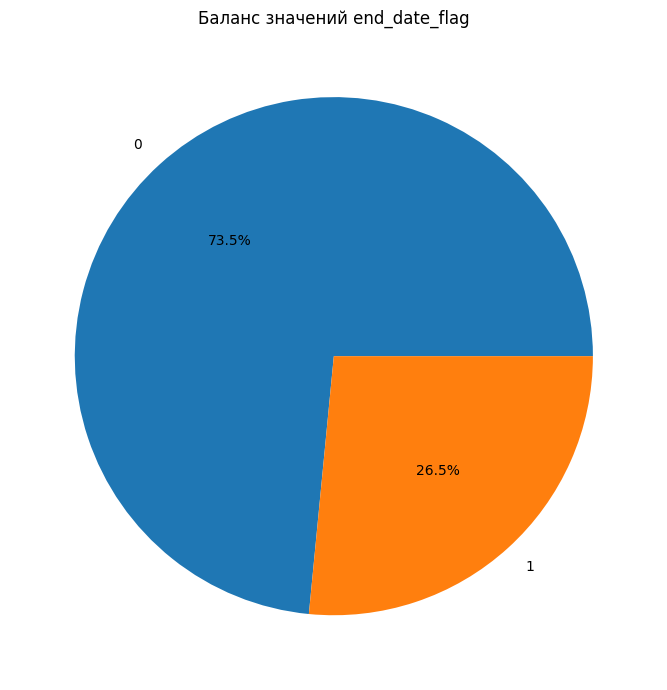

In [116]:
# ============================================================
# RUN 2. Missing values + target
# ============================================================

print("Пропуски ДО обработки:")
print(full_data_set.isna().sum())

missing_before = full_data_set.isna().sum()
missing_before = missing_before[missing_before > 0]

missing_before.to_csv("missing_before.csv")
mlflow.log_artifact("missing_before.csv", "eda")


# ------------------------------------------------------------
# Заполняем пропуски
# ------------------------------------------------------------

full_data_set["internet_service"] = (
    full_data_set["internet_service"]
    .fillna("No internet")
)

internet_dependent_cols = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

for col in internet_dependent_cols:
    full_data_set[col] = (
        full_data_set[col]
        .fillna("No internet")
    )

full_data_set["multiple_lines"] = (
    full_data_set["multiple_lines"]
    .fillna("No phone service")
)


print("\nПропуски ПОСЛЕ обработки:")
print(full_data_set.isna().sum())

missing_after = full_data_set.isna().sum()
missing_after = missing_after[missing_after > 0]

missing_after.to_csv("missing_after.csv")
mlflow.log_artifact("missing_after.csv", "eda")


# ------------------------------------------------------------
# TARGET
# ------------------------------------------------------------

full_data_set["end_date_flag"] = (
    full_data_set["end_date"]
    .apply(lambda x: 0 if pd.isna(x) else 1)
)

print("\nРаспределение target:")
print(full_data_set["end_date_flag"].value_counts())

target_counts = full_data_set["end_date_flag"].value_counts()

mlflow.log_metric(
    "target_class_0",
    int(target_counts.get(0, 0))
)

mlflow.log_metric(
    "target_class_1",
    int(target_counts.get(1, 0))
)


# ------------------------------------------------------------
# Target visualization
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

full_data_set["end_date_flag"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Баланс значений end_date_flag")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    "target_balance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

mlflow.log_artifact(
    "target_balance.png",
    "eda"
)

,monthly_charges,total_charges,contract_duration_days
count,7043.00,7032.00,7043.00
mean,64.76,2283.30,2754.99
std,30.09,2266.77,1500.04
min,18.25,18.80,30.00
25%,35.50,401.45,1767.00
50%,70.35,1397.48,3049.00
75%,89.85,3794.74,4022.00
max,118.75,8684.80,4599.00


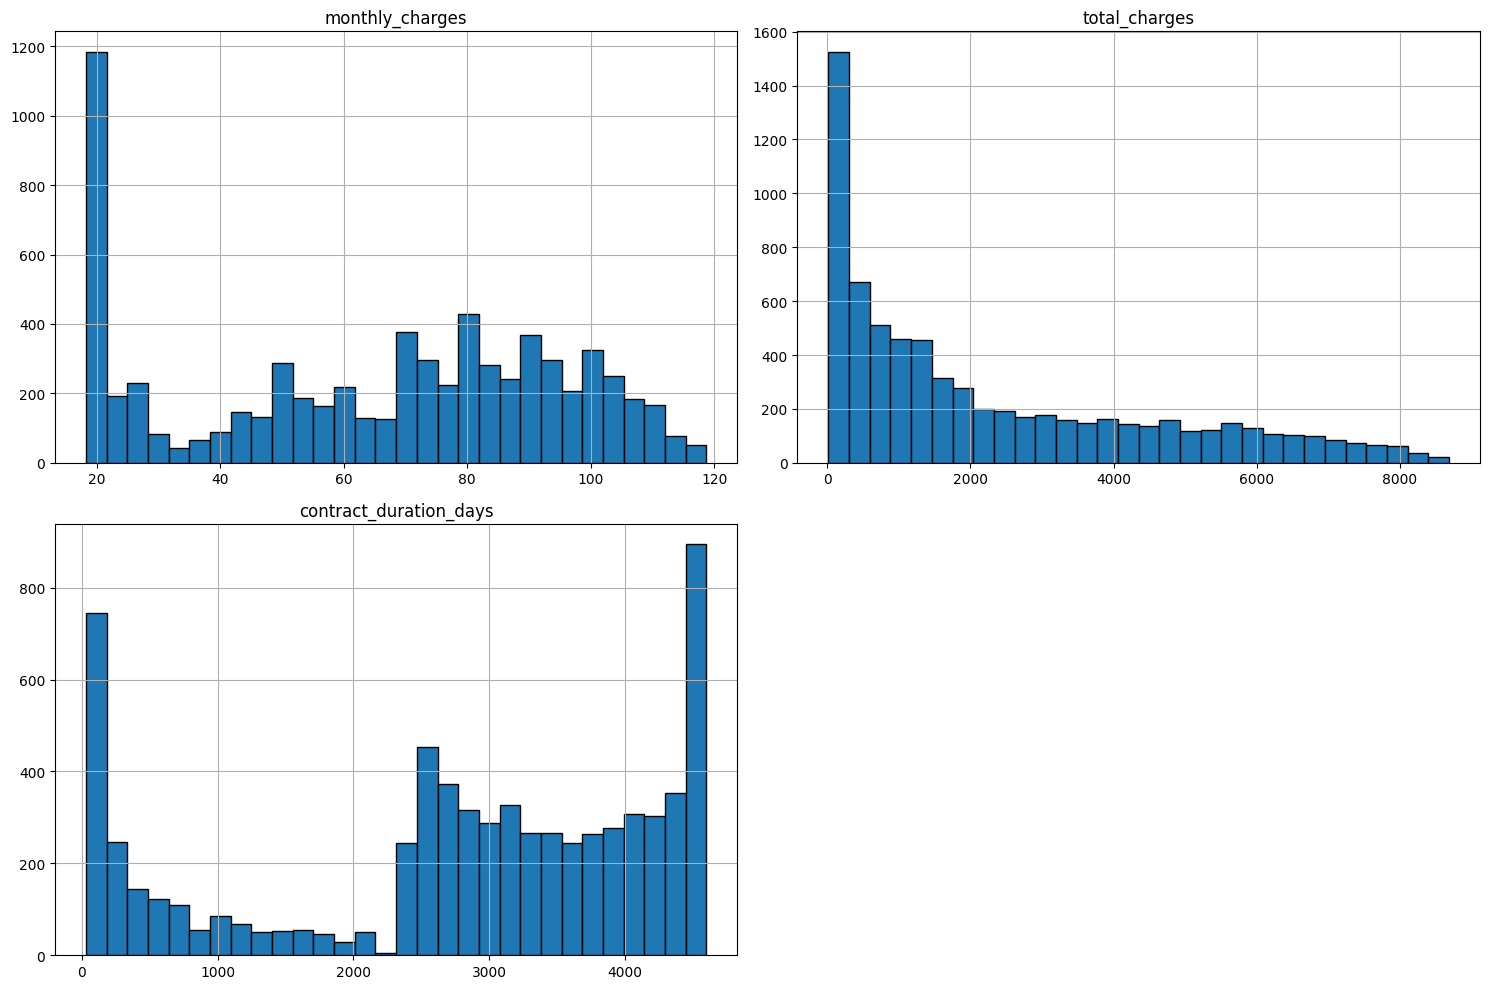

In [117]:
# ============================================================
# RUN 3. Dates + numerical features
# ============================================================

full_data_set["begin_date"] = pd.to_datetime(
    full_data_set["begin_date"],
    errors="coerce"
)

full_data_set["endDate"] = pd.to_datetime(
    full_data_set["end_date"],
    errors="coerce"
)

full_data_set["contract_duration_days"] = (
    full_data_set["endDate"].fillna(pd.Timestamp.today())
    - full_data_set["begin_date"]
).dt.days

full_data_set["contract_duration_months"] = (
    full_data_set["contract_duration_days"] / 30
).round()


# ------------------------------------------------------------
# Numerical features
# ------------------------------------------------------------

numeric_cols = [
    "monthly_charges",
    "total_charges",
    "contract_duration_days"
]

for col in numeric_cols:
    full_data_set[col] = pd.to_numeric(
        full_data_set[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

numeric_stats = (
    full_data_set[numeric_cols]
    .describe()
    .round(2)
)

display(numeric_stats)

numeric_stats.to_csv(
    "numeric_statistics.csv"
)

mlflow.log_artifact(
    "numeric_statistics.csv",
    "eda"
)


# ------------------------------------------------------------
# Distributions
# ------------------------------------------------------------

full_data_set[numeric_cols].hist(
    figsize=(15, 10),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()

plt.savefig(
    "numeric_distributions.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

mlflow.log_artifact(
    "numeric_distributions.png",
    "eda"
)

In [118]:
cols_to_drop = [
    'begin_date',
    'end_date',
    'endDate',
    'customer_id',
    'gender',
    'senior_citizen',
    'contract_duration_months',
    'target',
    'id',
    'contract_duration_days'
]
full_data_set = full_data_set.drop(
    columns=cols_to_drop,
    errors="ignore"
)

display(full_data_set.head())

,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,partner,dependents,multiple_lines,end_date_flag
0,Month-to-month,Yes,Mailed check,55.15,3673.15,DSL,Yes,No,Yes,No,No,No,Yes,No,No,0
1,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Yes,No,No phone service,0
2,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,No,No,No,No,No,No,No,No,No,1
3,Month-to-month,Yes,Electronic check,99.65,820.50,Fiber optic,No,No,Yes,No,Yes,Yes,No,No,Yes,1
4,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Fiber optic,No,Yes,No,No,Yes,No,No,Yes,Yes,0


In [119]:
# ============================================================
# RUN 6. Train / test + preprocessing
# ============================================================

RANDOM_STATE = 11225
TEST_SIZE = 0.25

X = full_data_set.drop(
    columns=["end_date_flag"]
)

y = full_data_set["end_date_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("\nTrain:", X_train.shape)
print("Test:", X_test.shape)

mlflow.log_param(
    "random_state",
    RANDOM_STATE
)

mlflow.log_param(
    "test_size",
    TEST_SIZE
)


# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------

ohe_columns = [
    "type",
    "payment_method",
    "internet_service",
    "multiple_lines"
]

ord_columns = [
    "paperless_billing",
    "partner",
    "dependents"
]

num_columns = [
    "total_charges",
    "monthly_charges"
]


numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "ohe",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


binary_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["No", "Yes"]
                ] * len(ord_columns)
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            num_columns
        ),
        (
            "cat",
            categorical_transformer,
            ohe_columns
        ),
        (
            "bin",
            binary_transformer,
            ord_columns
        )
    ]
)


Train: (5282, 15)
Test: (1761, 15)


In [120]:
# ============================================================
# RUN 7. Models + GridSearch
# ============================================================

gb_pipeline = Pipeline([
    (
        "pre",
        preprocessor
    ),
    (
        "clf",
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    )
])


rf_pipeline = Pipeline([
    (
        "pre",
        preprocessor
    ),
    (
        "clf",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])


lr_pipeline = Pipeline([
    (
        "pre",
        preprocessor
    ),
    (
        "pca",
        PCA()
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=5000
        )
    )
])


# ------------------------------------------------------------
# Parameter grids
# ------------------------------------------------------------

gb_param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3, 5]
}

rf_param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 10],
    "clf__min_samples_split": [2, 5]
}

lr_param_grid = {
    "pca__n_components": [5, 10, 15],
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["saga"]
}


cv = 5
scoring = "roc_auc"


gs_gb = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1
)

gs_rf = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1
)

gs_lr = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1
)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("Fitting GradientBoosting GridSearch...")
gs_gb.fit(X_train, y_train)

print("Fitting RandomForest GridSearch...")
gs_rf.fit(X_train, y_train)

print("Fitting LogisticRegression GridSearch...")
gs_lr.fit(X_train, y_train)


best_gb = gs_gb.best_estimator_
best_rf = gs_rf.best_estimator_
best_lr = gs_lr.best_estimator_

Fitting GradientBoosting GridSearch...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Fitting RandomForest GridSearch...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting LogisticRegression GridSearch...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [121]:
# ============================================================
# RUN 8. Model results + evaluation
# ============================================================

print("\nBest params GB:")
print(gs_gb.best_params_)

print("Best CV AUC GB:")
print(gs_gb.best_score_)

print("\nBest params RF:")
print(gs_rf.best_params_)

print("Best CV AUC RF:")
print(gs_rf.best_score_)

print("\nBest params LR:")
print(gs_lr.best_params_)

print("Best CV AUC LR:")
print(gs_lr.best_score_)


mlflow.log_metric(
    "gb_best_cv_auc",
    gs_gb.best_score_
)

mlflow.log_metric(
    "rf_best_cv_auc",
    gs_rf.best_score_
)

mlflow.log_metric(
    "lr_best_cv_auc",
    gs_lr.best_score_
)


# ------------------------------------------------------------
# Gradient Boosting test
# ------------------------------------------------------------

y_proba = best_gb.predict_proba(X_test)[:, 1]
y_pred = best_gb.predict(X_test)

auc_test = roc_auc_score(
    y_test,
    y_proba
)

acc_test = accuracy_score(
    y_test,
    y_pred
)

print("\n=== GradientBoosting Test Evaluation ===")
print(f"AUC-ROC: {auc_test:.4f}")
print(f"Accuracy: {acc_test:.4f}")

print(
    classification_report(
        y_test,
        y_pred
    )
)

mlflow.log_metric(
    "gb_test_auc",
    auc_test
)

mlflow.log_metric(
    "gb_test_accuracy",
    acc_test
)


Best params GB:
{'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}
Best CV AUC GB:
0.8406257959947379

Best params RF:
{'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
Best CV AUC RF:
0.8366649441952003

Best params LR:
{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'pca__n_components': 15}
Best CV AUC LR:
0.8317357353156988

=== GradientBoosting Test Evaluation ===
AUC-ROC: 0.8528
Accuracy: 0.8075
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1294
           1       0.67      0.53      0.59       467

    accuracy                           0.81      1761
   macro avg       0.76      0.72      0.73      1761
weighted avg       0.80      0.81      0.80      1761



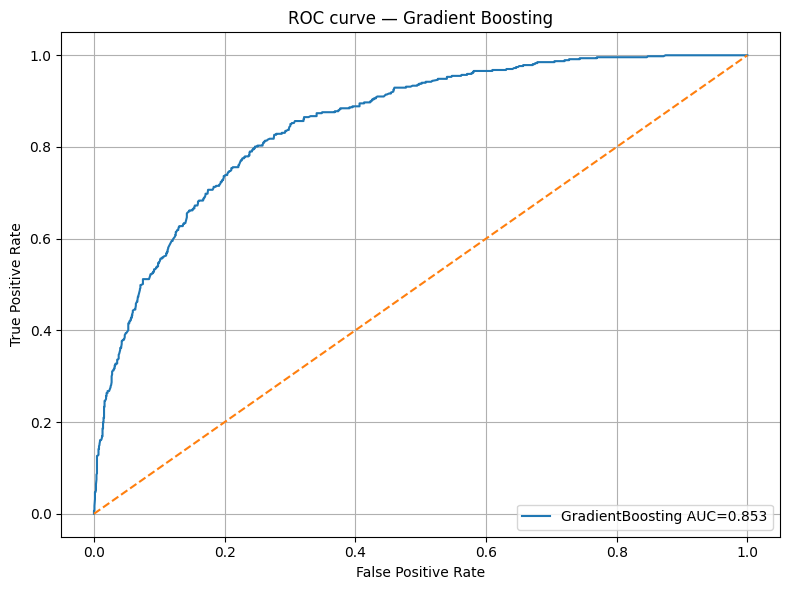

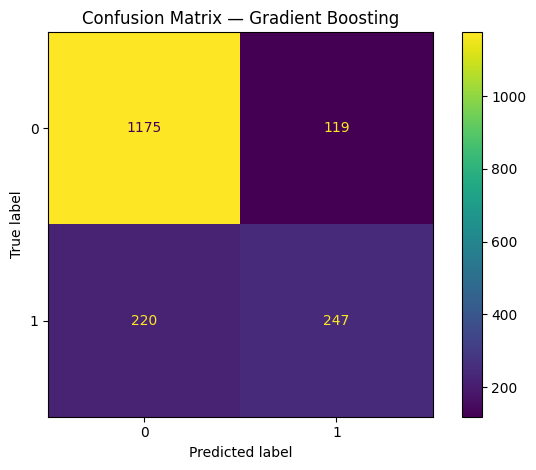

Number of feature names: 18
Number of importances: 18


,feature,importance
2,cat__type_Month-to-month,0.475739
0,num__total_charges,0.200706
10,cat__internet_service_Fiber optic,0.121856
1,num__monthly_charges,0.074647
7,cat__payment_method_Electronic check,0.057937
11,cat__internet_service_No internet,0.019922
15,bin__paperless_billing,0.018411
12,cat__multiple_lines_No,0.007625
4,cat__type_Two year,0.006864
3,cat__type_One year,0.005123


Model logged successfully.


In [122]:
# ============================================================
# RUN 9. Model evaluation artifacts
# ============================================================

# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"GradientBoosting AUC={auc_test:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — Gradient Boosting")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "roc_curve.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

mlflow.log_artifact(
    "roc_curve.png",
    "model_evaluation"
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    values_format="d"
)

plt.title(
    "Confusion Matrix — Gradient Boosting"
)

plt.grid(False)
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

mlflow.log_artifact(
    "confusion_matrix.png",
    "model_evaluation"
)


# ------------------------------------------------------------
# Feature importance
# ------------------------------------------------------------
preprocessor = best_gb.named_steps["pre"]
clf = best_gb.named_steps["clf"]

# Получаем имена признаков после preprocessing
feature_names = preprocessor.get_feature_names_out()

# Feature importance от GradientBoosting
importances = clf.feature_importances_

print(f"Number of feature names: {len(feature_names)}")
print(f"Number of importances: {len(importances)}")

# Проверка
if len(feature_names) != len(importances):
    raise ValueError(
        f"Feature names ({len(feature_names)}) "
        f"and importances ({len(importances)}) "
        f"have different lengths."
    )

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

display(
    importance_df.head(30)
)

importance_df.to_csv(
    "feature_importances.csv",
    index=False
)

mlflow.log_artifact(
    "feature_importances.csv",
    "model_evaluation"
)
# ============================================================
# RUN 9. Log trained model
# ============================================================
from mlflow.models import infer_signature
import mlflow.sklearn

input_example = X_train.head(5)

signature = infer_signature(
    X_train,
    best_gb.predict(X_train)
)

mlflow.sklearn.log_model(
    sk_model=best_gb,
    artifact_path="model",
    signature=signature,
    input_example=input_example
)

print("Model logged successfully.")


In [124]:
# ============================================================
# RUN 10. Final parameters + summary + finish run
# ============================================================

mlflow.log_param(
    "cv",
    cv
)

mlflow.log_param(
    "scoring",
    scoring
)

mlflow.log_param(
    "numeric_features",
    ", ".join(num_columns)
)

mlflow.log_param(
    "categorical_ohe_features",
    ", ".join(ohe_columns)
)

mlflow.log_param(
    "binary_features",
    ", ".join(ord_columns)
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

with open(
    "run_summary.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        f"Experiment: {EXPERIMENT_NAME}\n"
    )

    f.write(
        f"Run: {RUN_NAME}\n"
    )

    f.write(
        f"Rows before EDA: {rows_before}\n"
    )

    f.write(
        f"Rows after EDA: {len(full_data_set)}\n"
    )

    f.write(
        f"GB best CV AUC: "
        f"{gs_gb.best_score_:.6f}\n"
    )

    f.write(
        f"RF best CV AUC: "
        f"{gs_rf.best_score_:.6f}\n"
    )

    f.write(
        f"LR best CV AUC: "
        f"{gs_lr.best_score_:.6f}\n"
    )

    f.write(
        f"GB test AUC: "
        f"{auc_test:.6f}\n"
    )

    f.write(
        f"GB test Accuracy: "
        f"{acc_test:.6f}\n"
    )

mlflow.log_artifact(
    "run_summary.txt",
    "results"
)

# ============================================================
# RUN 10. Log training code
# ============================================================

mlflow.log_artifact(
    "users_churn.ipynb",
    artifact_path="code"
)

print("Training code logged successfully.")


# ------------------------------------------------------------
# Finish MLflow run
# ------------------------------------------------------------

mlflow.end_run()

print(f"\nRun ID: {run_id}")

run = mlflow.get_run(run_id)

print(f"Run status: {run.info.status}")

assert run.info.status == "FINISHED"


# ------------------------------------------------------------
# Cleanup local artifacts
# ------------------------------------------------------------

files_to_remove = [
    "missing_before.csv",
    "missing_after.csv",
    "target_balance.png",
    "numeric_statistics.csv",
    "numeric_distributions.png",
    "mann_whitney_results.csv",
    "phik_correlation.png",
    "categorical_features.png",
    "roc_curve.png",
    "confusion_matrix.png",
    "feature_importances.csv",
    "run_summary.txt"
]

for filename in files_to_remove:

    if os.path.exists(filename):
        os.remove(filename)


for col in numeric_cols:

    for prefix in ["kde_", "boxplot_"]:

        filename = f"{prefix}{col}.png"

        if os.path.exists(filename):
            os.remove(filename)

Training code logged successfully.

Run ID: ceab9b9ac4fc420789c1a073596fa094
Run status: FINISHED


In [130]:
# ============================================================
# MLflow connection
# ============================================================

# Закрываем старый локальный run
if mlflow.active_run() is not None:
    mlflow.end_run()

# Подключаемся к MLflow Tracking Server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5000


In [131]:
# ============================================================
# RUN 11. Log input data to S3
# ============================================================

# ------------------------------------------------------------
# Save input dataset locally
# ------------------------------------------------------------

input_data_path = "input_data.csv"

full_data_set.to_csv(
    input_data_path,
    index=False
)

print(f"Input data saved locally: {input_data_path}")


# ------------------------------------------------------------
# Log input dataset to MLflow
# ------------------------------------------------------------

mlflow.log_artifact(
    local_path=input_data_path,
    artifact_path="data"
)

print("Input data logged to MLflow.")


# ------------------------------------------------------------
# Show S3/object storage path
# ------------------------------------------------------------

active_run = mlflow.active_run()

if active_run is None:
    raise RuntimeError(
        "No active MLflow run. Start an MLflow run before logging artifacts."
    )

artifact_uri = active_run.info.artifact_uri

print("MLflow artifact URI:")
print(artifact_uri)

print("\nInput data artifact path:")
print(f"{artifact_uri}/data/input_data.csv")

Input data saved locally: input_data.csv


KeyboardInterrupt: 

In [132]:
import mlflow
print(mlflow.active_run())
print("Tracking URI:", mlflow.get_tracking_uri())

None
Tracking URI: http://127.0.0.1:5000
